In [6]:
pip install split-folders

Note: you may need to restart the kernel to use updated packages.


In [7]:
import tensorflow as tf
import matplotlib.pyplot as plt
import os

In [8]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/prakhar501
/kaggle/input/datasets/prakhar501/major-project-data-1
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Snow-Covered
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Dusty
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Electrical-damage
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Clean
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Bird-drop
/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data/Physical-Damage


In [10]:
import splitfolders
import kagglehub
INPUT_FOLDER = r"/kaggle/input/datasets/prakhar501/major-project-data-1/Project_Data/Data"      # Your original dataset
OUTPUT_FOLDER = "SolarPanelDataset_Split"

splitfolders.ratio(
    input=INPUT_FOLDER,
    output=OUTPUT_FOLDER,
    seed=42,
    ratio=(0.70, 0.15, 0.15),   # Train, Validation, Test
    group_prefix=None
)

print("Dataset split completed successfully!")

Copying files: 887 files [00:06, 128.87 files/s]

Dataset split completed successfully!


In [16]:
!pip install albumentations opencv-python

# **Image Augmentation**

In [17]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm
import albumentations as A

# Path to your training dataset
TRAIN_DIR = "/kaggle/working/SolarPanelDataset_Split/train"

# Target images per class
TARGET_IMAGES = 850

# Augmentation pipeline
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.7),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.7
    ),
    A.Affine(
        scale=(0.9, 1.1),
        translate_percent=(0.05, 0.05),
        rotate=(-10, 10),
        p=0.7
    ),
    A.GaussNoise(p=0.3),
])

# Supported image formats
IMG_EXTENSIONS = ('.jpg', '.jpeg', '.png', '.bmp')

for class_name in os.listdir(TRAIN_DIR):

    class_path = os.path.join(TRAIN_DIR, class_name)

    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(IMG_EXTENSIONS)]

    current_count = len(images)

    print(f"\n{class_name}")
    print(f"Original Images : {current_count}")

    if current_count >= TARGET_IMAGES:
        print("Already sufficient.")
        continue

    needed = TARGET_IMAGES - current_count

    print(f"Generating {needed} images...")

    for i in tqdm(range(needed)):

        img_name = random.choice(images)

        img_path = os.path.join(class_path, img_name)

        image = cv2.imread(img_path)

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        augmented = transform(image=image)

        aug_img = augmented["image"]

        save_name = f"aug_{i}_{img_name}"

        save_path = os.path.join(class_path, save_name)

        cv2.imwrite(save_path,
                    cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

    print("Done!")

print("\nDataset Augmentation Completed.")


Clean
Original Images : 135
Generating 715 images...


100%|██████████| 715/715 [01:02<00:00, 11.49it/s]


Done!

Bird-drop
Original Images : 144
Generating 706 images...


100%|██████████| 706/706 [00:19<00:00, 35.48it/s]


Done!

Electrical-damage
Original Images : 72
Generating 778 images...


...

Done!

Dusty
Original Images : 133
Generating 717 images...


100%|██████████| 717/717 [00:51<00:00, 13.97it/s]


Done!

Snow-Covered
Original Images : 86
Generating 764 images...


100%|██████████| 764/764 [00:17<00:00, 43.88it/s]

Done!

Dataset Augmentation Completed.


In [18]:
for cls in os.listdir(TRAIN_DIR):

    cls_path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(cls_path):
        print(cls, ":", len(os.listdir(cls_path)))

Clean : 850
Bird-drop : 851
Electrical-damage : 850
Physical-Damage : 850
Dusty : 850
Snow-Covered : 850


# **Loading the dataset**

In [30]:
Train_dir= "/kaggle/working/SolarPanelDataset_Split/train"
Test_dir= "/kaggle/working/SolarPanelDataset_Split/test"
Val_dir= "/kaggle/working/SolarPanelDataset_Split/val"
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32
SEED = 42

In [31]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    Train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)
test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)
val_dataset = tf.keras.utils.image_dataset_from_directory(
    Val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    seed = SEED
)

Found 5100 files belonging to 6 classes.
Found 137 files belonging to 6 classes.
Found 130 files belonging to 6 classes.


In [155]:
class_names = train_dataset.class_names
num_classes = len(class_names)
print(num_classes)
print(class_names)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

# **Base Model (CNN2D)**

In [33]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.MaxPooling2D((2,2)))

# Flattening
model.add(tf.keras.layers.Flatten())

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
EPOCHS=10

In [41]:
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = EPOCHS
)

Epoch 1/10


2026-07-23 09:40:49.081134: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 09:40:49.229679: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  3/160 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step - accuracy: 0.1476 - loss: 3.6315

I0000 00:00:1784799651.994258     165 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.3408 - loss: 1.8362

2026-07-23 09:41:13.111982: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 09:41:13.256577: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 160ms/step - accuracy: 0.4196 - loss: 1.5102 - val_accuracy: 0.4154 - val_loss: 1.3859
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.6155 - loss: 1.0432 - val_accuracy: 0.5692 - val_loss: 1.2553
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.7516 - loss: 0.6977 - val_accuracy: 0.6308 - val_loss: 1.2287
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8573 - loss: 0.4138 - val_accuracy: 0.6308 - val_loss: 1.5450
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.9173 - loss: 0.2421 - val_accuracy: 0.7154 - val_loss: 1.4306
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.9559 - loss: 0.1311 - val_accuracy: 0.7000 - val_loss: 1.7622
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.9608 - loss: 0.1187 - val_accuracy: 0.7077 - val_loss: 1.8138
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.9845 - loss: 0.0588 - val

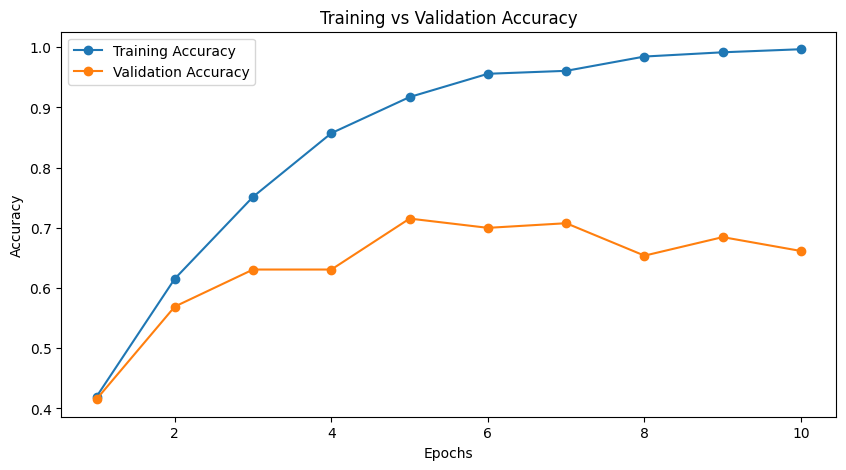

In [42]:
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, EPOCHS + 1)

plt.figure(figsize= (10,5))
plt.plot(epochs, train_accuracy, label = 'Training Accuracy', marker = 'o')
plt.plot(epochs, val_accuracy, label = 'Validation Accuracy', marker = 'o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# **Solving the Overfitting Problem**

In [43]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

In [45]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch,lr):
  if epoch > 5:
    return lr*0.1
  return lr

lr_schedule = LearningRateScheduler(scheduler)

In [46]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Rescaling(1.0/255, input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)))

# Convolution layer: 1
model.add(tf.keras.layers.Conv2D(32, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 2
model.add(tf.keras.layers.Conv2D(64, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Convolution layer: 3
model.add(tf.keras.layers.Conv2D(128, (3,3), activation="relu"))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D((2,2)))
model.add(tf.keras.layers.Dropout(0.3))

# Flattening
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dropout(0.5))

# FCL
model.add(tf.keras.layers.Dense(128, activation="relu"))

# Output layer
model.add(tf.keras.layers.Dense(num_classes, activation="softmax"))

In [47]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [48]:
history = model.fit(
    train_dataset,
    validation_data = val_dataset,
    epochs = 20
)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 33s 161ms/step - accuracy: 0.2696 - loss: 4.4205 - val_accuracy: 0.2385 - val_loss: 14.7987
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.4182 - loss: 1.4450 - val_accuracy: 0.2769 - val_loss: 10.0779
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.5196 - loss: 1.2522 - val_accuracy: 0.2923 - val_loss: 11.3326
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.5984 - loss: 1.0327 - val_accuracy: 0.4692 - val_loss: 2.9568
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.6796 - loss: 0.8604 - val_accuracy: 0.5231 - val_loss: 2.1578
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7276 - loss: 0.7232 - val_accuracy: 0.4154 - val_loss: 3.0924
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.7582 - loss: 0.6425 - val_accuracy: 0.4923 - val_loss: 2.2809
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.7945 - loss

In [49]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy*100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 284ms/step - accuracy: 0.7299 - loss: 2.5367
Test Loss     : 2.5367
Test Accuracy : 72.99%


# MobileNetV2

# Preprocessing the Images for MobileNetV2

In [95]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# MobileNet input size
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Load datasets
train_dataset = tf.keras.utils.image_dataset_from_directory(
    Train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    Val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

# Apply MobileNet preprocessing
train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

# Improve input pipeline performance
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

Found 5100 files belonging to 6 classes.
Found 137 files belonging to 6 classes.
Found 130 files belonging to 6 classes.


In [96]:
#MobileNetV2 base model

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

In [97]:
base_model.trainable = False

model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Input(shape=(224,224,3)))
model.add(base_model)

model.add(tf.keras.layers.GlobalAveragePooling2D())

model.add(tf.keras.layers.Dropout(0.3))

model.add(tf.keras.layers.Dense(128, activation='relu'))

model.add(tf.keras.layers.Dropout(0.4))

model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))

In [103]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_9      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [105]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [106]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 200ms/step - accuracy: 0.5692 - loss: 1.1316 - val_accuracy: 0.7154 - val_loss: 0.7440 - learning_rate: 0.0010
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.7459 - loss: 0.7097 - val_accuracy: 0.7615 - val_loss: 0.6151 - learning_rate: 0.0010
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7920 - loss: 0.5585 - val_accuracy: 0.7769 - val_loss: 0.5802 - learning_rate: 0.0010
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.8194 - loss: 0.4986 - val_accuracy: 0.8077 - val_loss: 0.5641 - learning_rate: 0.0010
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8363 - loss: 0.4393 - val_accuracy: 0.8077 - val_loss: 0.5834 - learning_rate: 0.0010
Epoch 6/20
159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.8653 - loss: 0.3795
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.85

In [107]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Accuracy : {test_accuracy*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.7715 - loss: 0.5751

2026-07-23 10:59:56.299744: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 10:59:56.443826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-23 10:59:56.579837: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.8102 - loss: 0.5247  
Test Accuracy : 81.02%
Test Loss     : 0.5247


# **GPT's Advice Fine Tuning**

In [78]:
# Unfreeze the MobileNet base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

In [79]:
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 139ms/step - accuracy: 0.9365 - loss: 0.1752 - val_accuracy: 0.7923 - val_loss: 0.7794 - learning_rate: 4.0000e-05
Epoch 2/10
159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9413 - loss: 0.1607
Epoch 2: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.9402 - loss: 0.1620 - val_accuracy: 0.7846 - val_loss: 0.7975 - learning_rate: 4.0000e-05
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 135ms/step - accuracy: 0.9433 - loss: 0.1590 - val_accuracy: 0.7846 - val_loss: 0.8004 - learning_rate: 8.0000e-06
Epoch 4/10
159/160 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9473 - loss: 0.1472
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.
160/160 ━━━━━━━━━━━━━━━━━━━━ 22s 134ms/step - accuracy: 0.9433 - loss: 0.1553 - val_accuracy: 0.7846 - val_loss: 0.8014 - learning_rate: 8.0000e-06
Epoch 4: early stopping
Restoring model weights from the 

# **EffientNetB0**

In [109]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras import regularizers
import tensorflow as tf

In [114]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    Train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    Val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5100 files belonging to 6 classes.
Found 130 files belonging to 6 classes.
Found 137 files belonging to 6 classes.


In [115]:
train_dataset = train_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (tf.cast(x, tf.float32), y)
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [117]:
for images, labels in train_dataset.take(1):
    print(images.dtype)
    print(tf.reduce_min(images).numpy())
    print(tf.reduce_max(images).numpy())

<dtype: 'float32'>
0.0
255.0


In [118]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

In [120]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [122]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_11     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,379,049 (16.70 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [125]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [126]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 61s 252ms/step - accuracy: 0.4288 - loss: 1.8712 - val_accuracy: 0.6154 - val_loss: 1.4164 - learning_rate: 1.0000e-04
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.6629 - loss: 1.3700 - val_accuracy: 0.7077 - val_loss: 1.2075 - learning_rate: 1.0000e-04
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7143 - loss: 1.2110 - val_accuracy: 0.7385 - val_loss: 1.1188 - learning_rate: 1.0000e-04
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.7461 - loss: 1.1050 - val_accuracy: 0.7538 - val_loss: 1.0624 - learning_rate: 1.0000e-04
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 129ms/step - accuracy: 0.7776 - loss: 1.0146 - val_accuracy: 0.8077 - val_loss: 1.0098 - learning_rate: 1.0000e-04
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7900 - loss: 0.9782 - val_accuracy: 0.8154 - val_loss: 0.9822 - learning_rate: 1.0000e-04
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 12

In [127]:
test_loss, test_acc = model.evaluate(test_dataset)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss : {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.8905 - loss: 0.6305  
Test Accuracy : 89.05%
Test Loss : 0.6305


In [144]:
model.save("efficientnetb0.keras")

In [148]:
import shutil

shutil.make_archive(
    "/kaggle/working/model",
    "zip",
    "/kaggle/working",
    "efficientnetb0.keras"
)

'/kaggle/working/model.zip'

In [151]:
import pickle

class_names =train_dataset.class_names

with open("/kaggle/working/class_names.pkl", "wb") as f:
    pickle.dump(class_names, f)

AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

# **Fine Tuning using GPT**

In [129]:
base_model.trainable = True

for layer in base_model.layers[:-40]:
    layer.trainable = False

In [130]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [131]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [132]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=7,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 74s 284ms/step - accuracy: 0.7602 - loss: 1.0126 - val_accuracy: 0.8000 - val_loss: 0.8658 - learning_rate: 1.0000e-05
Epoch 2/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.8133 - loss: 0.8654 - val_accuracy: 0.8154 - val_loss: 0.8738 - learning_rate: 1.0000e-05
Epoch 3/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.8418 - loss: 0.7847 - val_accuracy: 0.8154 - val_loss: 0.8496 - learning_rate: 1.0000e-05
Epoch 4/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8629 - loss: 0.7185 - val_accuracy: 0.8154 - val_loss: 0.8280 - learning_rate: 1.0000e-05
Epoch 5/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 130ms/step - accuracy: 0.8725 - loss: 0.6805 - val_accuracy: 0.8154 - val_loss: 0.8116 - learning_rate: 1.0000e-05
Epoch 6/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.8835 - loss: 0.6491 - val_accuracy: 0.8154 - val_loss: 0.7952 - learning_rate: 1.0000e-05
Epoch 7/7
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/ste

# **ResNet50**

# Reloading Dataset

In [133]:
import tensorflow as tf

IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    Train_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    Val_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    Test_dir,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 5100 files belonging to 6 classes.
Found 130 files belonging to 6 classes.
Found 137 files belonging to 6 classes.


In [134]:
from tensorflow.keras.applications.resnet50 import preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

val_dataset = val_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(tf.cast(x, tf.float32)), y)
)

AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
val_dataset = val_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

In [136]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import regularizers

In [137]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [138]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224,224,3)),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.4),

    tf.keras.layers.Dense(
        256,
        activation='relu',
        kernel_regularizer=regularizers.l2(0.001)
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        num_classes,
        activation='softmax'
    )
])

In [139]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [140]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [141]:
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 49s 223ms/step - accuracy: 0.3449 - loss: 2.4498 - val_accuracy: 0.6231 - val_loss: 1.4479 - learning_rate: 1.0000e-04
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.5510 - loss: 1.6744 - val_accuracy: 0.6692 - val_loss: 1.3086 - learning_rate: 1.0000e-04
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.6137 - loss: 1.4770 - val_accuracy: 0.7462 - val_loss: 1.2041 - learning_rate: 1.0000e-04
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 153ms/step - accuracy: 0.6676 - loss: 1.3289 - val_accuracy: 0.7385 - val_loss: 1.1252 - learning_rate: 1.0000e-04
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 154ms/step - accuracy: 0.7051 - loss: 1.2275 - val_accuracy: 0.7538 - val_loss: 1.0768 - learning_rate: 1.0000e-04
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 157ms/step - accuracy: 0.7269 - loss: 1.1518 - val_accuracy: 0.8000 - val_loss: 1.0343 - learning_rate: 1.0000e-04
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 25s 15

In [142]:
test_loss, test_acc = model.evaluate(test_dataset)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss : {test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 914ms/step - accuracy: 0.8978 - loss: 0.7153
Test Accuracy : 89.78%
Test Loss : 0.7153
